## 1) Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import(
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

## 2) Load Cleaned Dataset

In [3]:
# import os
# os.listdir('data')
movie_features = pd.read_csv('data/movie_features.csv')

## 3) Train/Test Split

In [4]:
# Features
X = movie_features[
    ['avg_rating',
    'rating_count',
    'tag_count']
]
y = movie_features['engagement_score']    # target

In [5]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.2,
    random_state=42
)

## 4) Train Model

- Rigde Regression và Random Forest Regression
### 4.1. Buil Rigde Regression
- Linear Regression: y = wX + b
- Rigde Regularization: Loss = 1/n tổng(y - y_pred)^2 + lambda tổngw^2

In [6]:
class RidgeRegressionH:
    def __init__(
        self,
        learning_rate=0.01,
        epochs=1000,
        alpha=1.0
):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha

        self.weights = None
        self.bias = None

        self.losses = []
    
    # Train
    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):
            # Prediction
            y_pred = np.dot(X, self.weights) + self.bias

            # Compute Loss
            mse = np.mean((y-y_pred)**2)

            ridge_penalty = (self.alpha * np.sum(self.weights**2))

            loss = mse + ridge_penalty
            self.losses.append(loss)

            # Gradients
            dw = ((1/n_samples) * np.dot(X.T, (y_pred - y))) + ((2 * self.alpha / n_samples) * self.weights)
            db = (1/n_samples) * np.sum(y_pred - y)

            # Update weights and bias
            self.weights = self.weights - self.learning_rate * dw
            self.bias = self.bias - self.learning_rate * db
    # Predict
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [7]:
## Convert sang numpy
X_train_np = X_train.values
X_test_np = X_test.values

y_train_np = y_train.values
y_test_np = y_test.values

#### Train

In [8]:
ridge = RidgeRegressionH(
    learning_rate=0.001,
    epochs=300,
    alpha=1.0
)

ridge.fit(
    X_train_np,
    y_train_np
)

#### PLot loss function

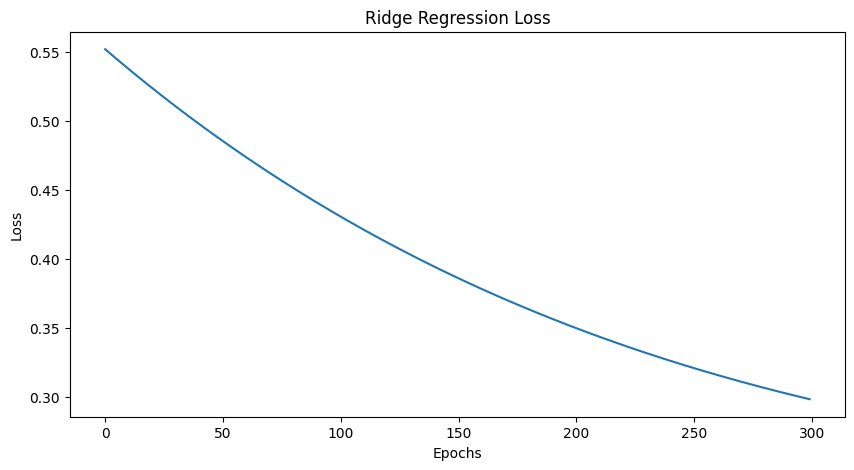

In [9]:
plt.figure(figsize=(10,5))
plt.plot(ridge.losses)
plt.title("Ridge Regression Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

#### Predict

In [10]:
ridge_pred = ridge.predict(
    X_test_np
)

### 4.2. Evaluation

In [11]:
print("MSE:", mean_squared_error(y_test_np, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_np, ridge_pred)))
print("R2 Score:", r2_score(y_test_np, ridge_pred))

MSE: 0.22126712878136837
RMSE: 0.4703904003924489
R2 Score: 0.5243050141440928


In [12]:
class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        value=None
    ):

        self.feature = feature
        self.threshold = threshold

        self.left = left
        self.right = right

        self.value = value

In [13]:
class DecisionTreeRegressorCustom:

    def __init__(
        self,
        max_depth=5,
        min_samples_split=2
    ):

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

        self.root = None
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        self.root = self._grow_tree(
            X,
            y
        )
    def _grow_tree(
        self,
        X,
        y,
        depth=0
    ):

        n_samples, n_features = X.shape


        # Stop conditions
        if (
            depth >= self.max_depth
            or n_samples < self.min_samples_split
        ):

            leaf_value = np.mean(y)

            return Node(
                value=leaf_value
            )


        best_feature = None
        best_threshold = None
        best_mse = float('inf')


        # Find best split
        for feature in range(n_features):

            thresholds = np.unique(
                X[:, feature]
            )

            for threshold in thresholds:

                left_idx = (
                    X[:, feature]
                    <= threshold
                )

                right_idx = (
                    X[:, feature]
                    > threshold
                )


                if (
                    np.sum(left_idx) == 0
                    or np.sum(right_idx) == 0
                ):

                    continue


                left_y = y[left_idx]
                right_y = y[right_idx]


                mse = (
                    self._mse(left_y)
                    * len(left_y)
                    +
                    self._mse(right_y)
                    * len(right_y)
                ) / n_samples


                if mse < best_mse:

                    best_mse = mse

                    best_feature = feature
                    best_threshold = threshold


        # Split data
        left_idx = (
            X[:, best_feature]
            <= best_threshold
        )

        right_idx = (
            X[:, best_feature]
            > best_threshold
        )


        left = self._grow_tree(
            X[left_idx],
            y[left_idx],
            depth + 1
        )

        right = self._grow_tree(
            X[right_idx],
            y[right_idx],
            depth + 1
        )


        return Node(
            feature=best_feature,
            threshold=best_threshold,
            left=left,
            right=right
        )
    def _mse(self, y):

        if len(y) == 0:
            return 0

        return np.mean(
            (y - np.mean(y)) ** 2
        )
    def predict(self, X):

        X = np.array(X)

        predictions = [
            self._traverse_tree(
                x,
                self.root
            )
            for x in X
        ]

        return np.array(predictions)
    def _traverse_tree(
        self,
        x,
        node
    ):

        # Leaf node
        if node.value is not None:

            return node.value


        if (
            x[node.feature]
            <= node.threshold
        ):

            return self._traverse_tree(
                x,
                node.left
            )

        return self._traverse_tree(
            x,
            node.right
        )

In [14]:
tree = DecisionTreeRegressorCustom(
    max_depth=5
)

tree.fit(
    X_train,
    y_train
)


In [15]:
tree_pred = tree.predict(X_test)

In [16]:
print(
    "MSE:",
    mean_squared_error(
        y_test,
        tree_pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            tree_pred
        )
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        tree_pred
    )
)

MSE: 0.016979828715823733
RMSE: 0.13030667180088568
R2 Score: 0.9634956198632174


#### Compare Model

In [19]:
results = pd.DataFrame({
    'Model': [
        'Custom Ridge Regression',
        'Custom Decision Tree'
    ],
    'RMSE': [
        0.470,
        0.130
    ],
    'R2 Score': [
        0.524,
        0.963
    ]
})
results

,Model,RMSE,R2 Score
0,Custom Ridge Regression,0.47,0.524
1,Custom Decision Tree,0.13,0.963


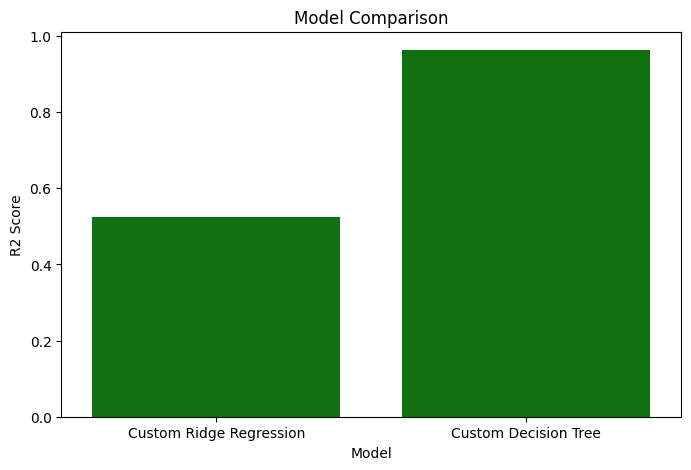

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    color ='green',
    data=results
)

plt.title("Model Comparison")

plt.show()

#### Difference between Actual and Predicted Values

In [31]:
pred_df = pd.DataFrame({

    'Actual': y_test,

    'Predicted': tree_pred,

    'Difference': y_test - tree_pred,

    'Absolute Error': np.abs(
        y_test - tree_pred
    )

})

pred_df.head(5)

,Actual,Predicted,Difference,Absolute Error
1145,0.881218,0.668181,0.213036,0.213036
8505,0.394324,0.400833,-0.006509,0.006509
3903,1.069830,1.057486,0.012344,0.012344
1608,0.262573,0.256645,0.005928,0.005928
9141,0.219329,0.256645,-0.037316,0.037316


#### Actual with Predicted Plot

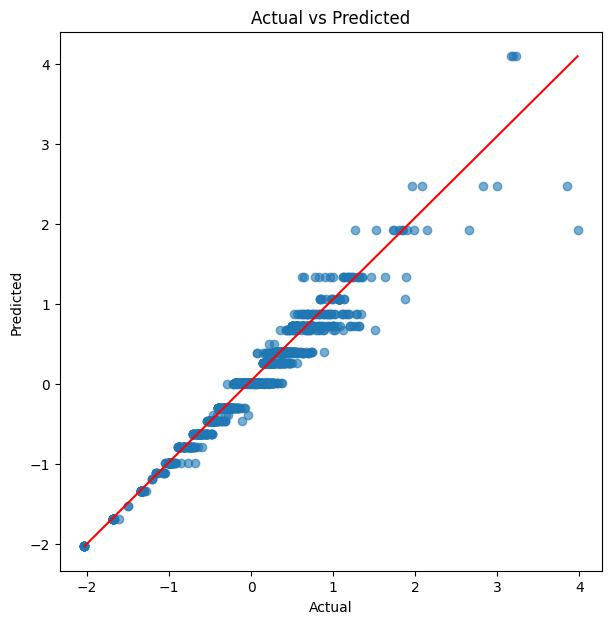

In [37]:
plt.figure(figsize=(7,7))

plt.scatter(
    pred_df['Actual'],
    pred_df['Predicted'],
    alpha=0.6
)

plt.plot(
    [
        pred_df['Actual'].min(),
        pred_df['Actual'].max()
    ],
    [
        pred_df['Predicted'].min(),
        pred_df['Predicted'].max()
    ],
    color='red',
    linestyle=("-")
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(
    "Actual vs Predicted"
)

plt.show()